Pipeline template

Notebook to illustrate the overall pipeline flow including:

- reading in data
- adding non signal noise
- modifying record to be input ready
- inputting to DMD
- converting recovered outputs to comparable outputs
- examining recovery metrics

## Preamble

In [107]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [108]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pydmd import DMD, BOPDMD
from pydmd.preprocessing import hankel_preprocessing
from matplotlib.colors import BoundaryNorm


# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Application


## Reading in global data

In [109]:
# Defining test parameters

# defining modes used
mode_numbers = ['62', '6', '13', '48', '45', '1', '32']
mode_numbers = [str(mode_number) for mode_number in mode_numbers]

# getting full (nmax=15) unperturbed records and synthetic suite info
record_dict_global, syn_suite_info_global = Record_Dict_Construct(mode_numbers=mode_numbers, nmax=15)

# defining notebook global colours for each mode in plotting
for i, mode_key in enumerate(syn_suite_info_global):
    syn_suite_info_global[mode_key]["colour"] = tol_muted[i % len(tol_muted)]

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.589783774436027e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 3011650.983171537. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 476944.82513753616. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 1.8830235423143812e+16. Consider preprocessing data, passing in augmented data
ma

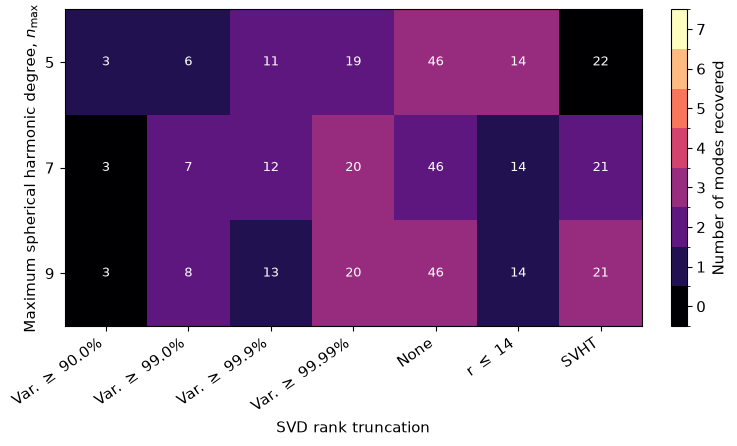

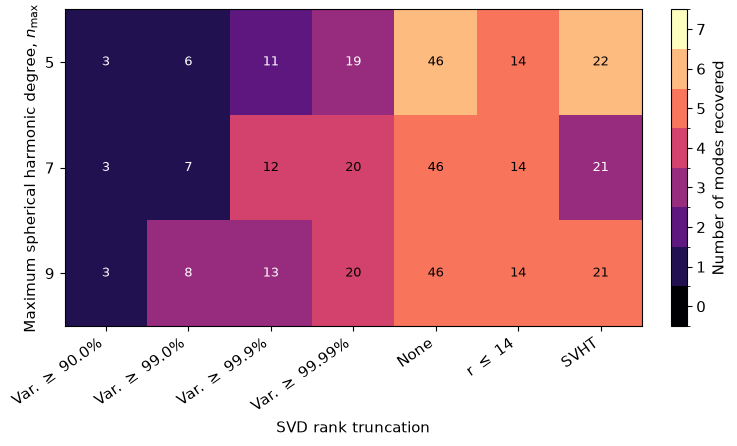

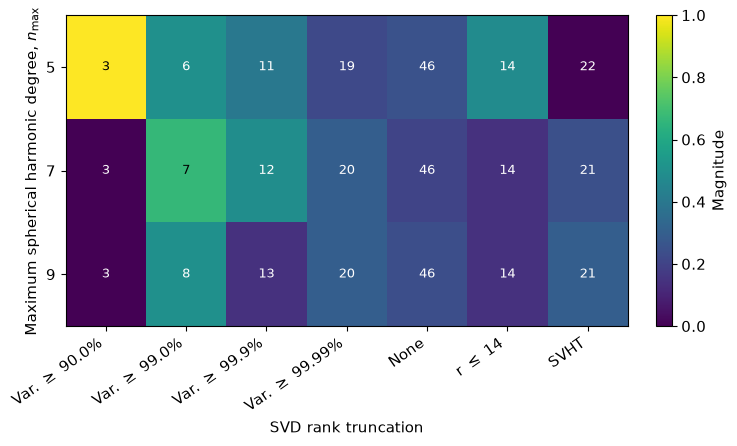

In [212]:

# nmax values to test
nmax_list = [5,7,9]

# svd rank values to test
svd_rank_list = [0.9, 0.99, 0.999, 0.9999, -1, 2*len(mode_numbers), 0]

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":3,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":10,
    "record_for_ensemble":"background"
}


Rank_Degree_Heatmap(record_dict_global, syn_suite_info_global, 
                    nmax_list, svd_rank_list, 
                    dmd_settings, ensemble_settings)



In [208]:
# specific exact case

dmd_settings = {
    "dmd_type":"opdmd",
    "hankel_flag":True,
    "embedding_d":3,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":100,
    "record_for_ensemble":"background"
}

nmax_choice = 9
svd_rank_choice = 0.9999

# getting output of dmd for a run with a specific nmax, svd rank
results_dict, total_unmatched_periods, rec_modes = Pipeline_Run(record_dict_global, syn_suite_info_global, 
        dmd_settings, nmax=nmax_choice, svd_rank=svd_rank_choice,
        ensemble_settings=ensemble_settings, total_unmatched_period_return=True)


results_dict = Ensemble_To_Median(results_dict, syn_suite_info_global)


fail
fail


/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/bopdmd.py:973: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)


fail
fail


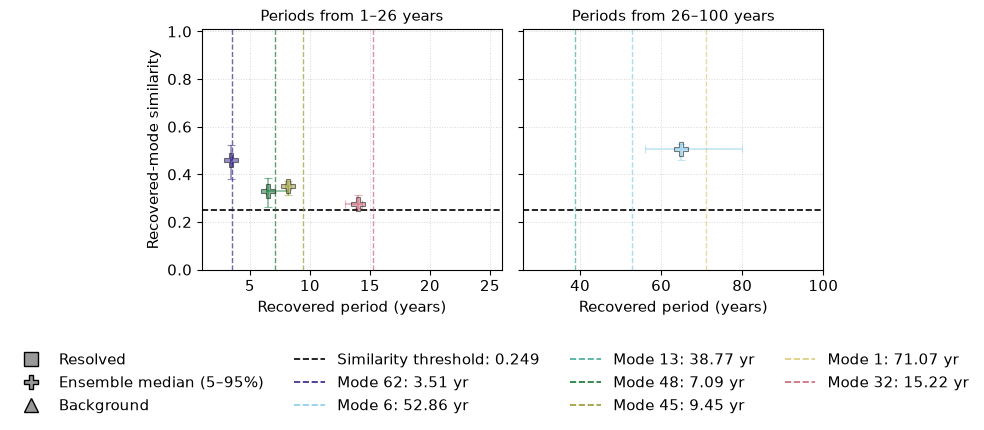

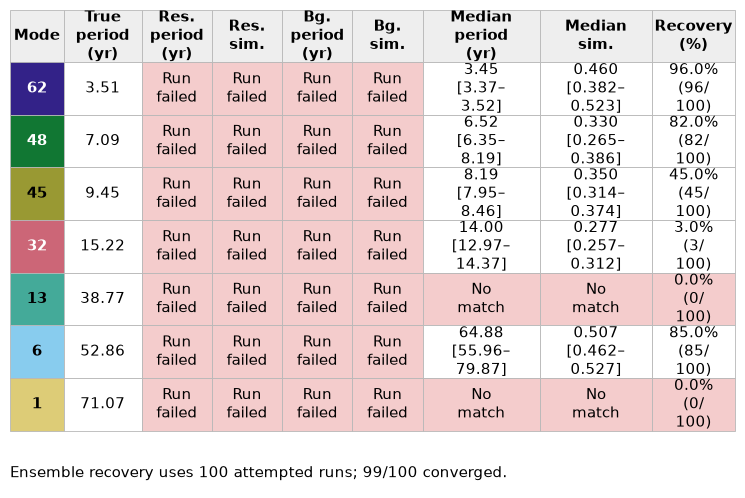

In [209]:
similarity_threshold = similarity_thresholds[
    "background"
][str(nmax_choice)]

records_to_include = ["resolved", "background","median"]

similarity_figure, similarity_axes = Plot_Period_Similarity_Results(
    results_dict, syn_suite_info_global, similarity_threshold,
    record_markers, record_plotting_params, figure_width=text_width,
)

summary_figure, summary_table = Results_Summary_Table(results_dict, syn_suite_info_global,
    records_to_include=records_to_include, ensemble_percentage_basis="attempted",
)
plt.show()

In [210]:
# from ensemble result, get period points by match
def By_Mode_Results(results_dict, mode_numbers):

    mode_period_recoveries = {}

    for mode_key in mode_numbers:
        mode_period_recoveries[mode_key] = []


    ensemble_result_dict = results_dict["ensemble"]

    for ensemble_i_key in ensemble_result_dict:
        ensemble_i_dict = ensemble_result_dict[ensemble_i_key]
        for mode_key in ensemble_i_dict:
            if ensemble_i_dict[mode_key] and type(ensemble_i_dict[mode_key])!=int:

                period = ensemble_i_dict[mode_key]["match_period"]
                mode_period_recoveries[mode_key].append(period)


    return(mode_period_recoveries)

by_mode_period_recoveries = By_Mode_Results(results_dict, mode_numbers)

TypeError: 'NoneType' object is not iterable

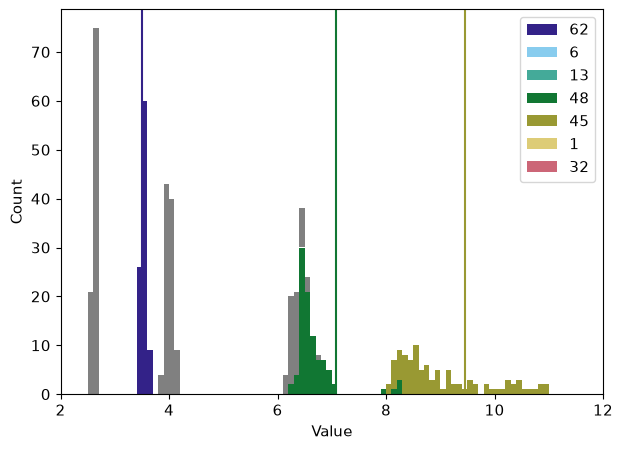

In [211]:
mode_keys = list(syn_suite_info_global.keys())
values = [by_mode_period_recoveries[key] for key in mode_keys] + [total_unmatched_periods]
colours = [syn_suite_info_global[key]["colour"] for key in mode_keys] + ["Gray"]

plt.figure(figsize=(7, 5))



for mode_key in syn_suite_info_global:
   plt.axvline(syn_suite_info_global[mode_key]["true_period"], color=syn_suite_info_global[mode_key]["colour"])


plt.hist(
    values,
    bins=100,
    stacked=True,
    color=colours,
    label=mode_keys,
    range=(2, 12)
)

plt.xlim((2, 12))
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.show()

In [50]:
# code to convert recovered modes into suite type data set
def Recovered_Modes_To_Suite(recovered_modes):

    recovered_suite = {}

    output_phasors = recovered_modes["phasors"]
    output_eigenvalues = recovered_modes["continuous_eigenvalues"]

    for output_num, (output_phasor, output_eig) in enumerate(zip(output_phasors, output_eigenvalues)):
        recovered_suite[output_num] = {
            "phasor":output_phasor,
            "eigenvalue":output_eig
        }

    return(recovered_suite)

In [138]:
recovered_suite = Recovered_Modes_To_Suite(rec_modes)

(<Figure size 725x1400 with 21 Axes>,
 array([[<Axes: title={'center': '62: real component\nPeriod = 3.51 years'}, xlabel='Longitude (°)', ylabel='Latitude (°)'>,
         <Axes: title={'center': '62: imaginary component\nPeriod = 3.51 years'}, xlabel='Longitude (°)'>],
        [<Axes: title={'center': '48: real component\nPeriod = 7.09 years'}, xlabel='Longitude (°)', ylabel='Latitude (°)'>,
         <Axes: title={'center': '48: imaginary component\nPeriod = 7.09 years'}, xlabel='Longitude (°)'>],
        [<Axes: title={'center': '45: real component\nPeriod = 9.45 years'}, xlabel='Longitude (°)', ylabel='Latitude (°)'>,
         <Axes: title={'center': '45: imaginary component\nPeriod = 9.45 years'}, xlabel='Longitude (°)'>],
        [<Axes: title={'center': '32: real component\nPeriod = 15.22 years'}, xlabel='Longitude (°)', ylabel='Latitude (°)'>,
         <Axes: title={'center': '32: imaginary component\nPeriod = 15.22 years'}, xlabel='Longitude (°)'>],
        [<Axes: title={'cent

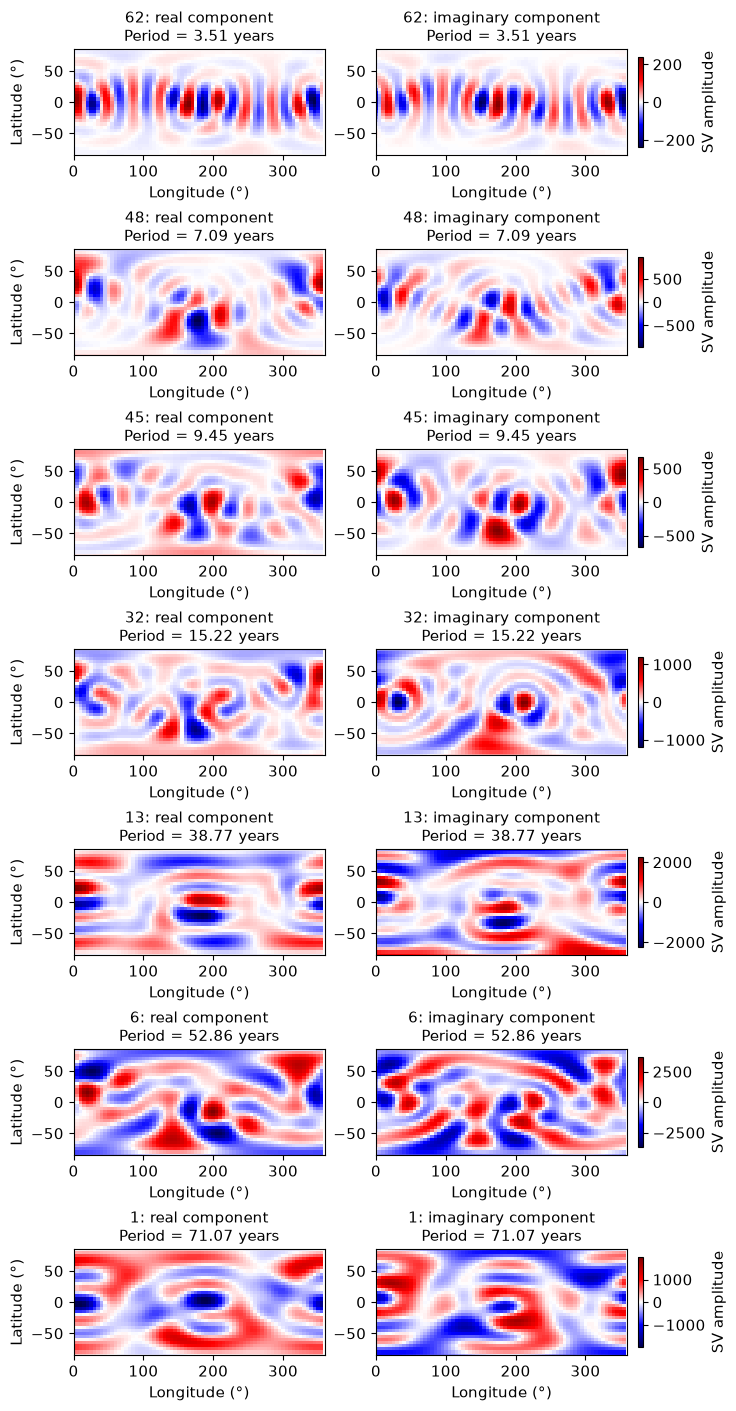

In [103]:
Plot_Mode_Phasors(syn_suite_info_global, nmax=9)

(<Figure size 725x800 with 12 Axes>,
 array([[<Axes: title={'center': '0: real component\nPeriod = 7.64 years'}, xlabel='Longitude (°)', ylabel='Latitude (°)'>,
         <Axes: title={'center': '0: imaginary component\nPeriod = 7.64 years'}, xlabel='Longitude (°)'>],
        [<Axes: title={'center': '3: real component\nPeriod = 11.66 years'}, xlabel='Longitude (°)', ylabel='Latitude (°)'>,
         <Axes: title={'center': '3: imaginary component\nPeriod = 11.66 years'}, xlabel='Longitude (°)'>],
        [<Axes: title={'center': '2: real component\nPeriod = 22.85 years'}, xlabel='Longitude (°)', ylabel='Latitude (°)'>,
         <Axes: title={'center': '2: imaginary component\nPeriod = 22.85 years'}, xlabel='Longitude (°)'>],
        [<Axes: title={'center': '1: real component\nPeriod = 62.97 years'}, xlabel='Longitude (°)', ylabel='Latitude (°)'>,
         <Axes: title={'center': '1: imaginary component\nPeriod = 62.97 years'}, xlabel='Longitude (°)'>]],
       dtype=object))

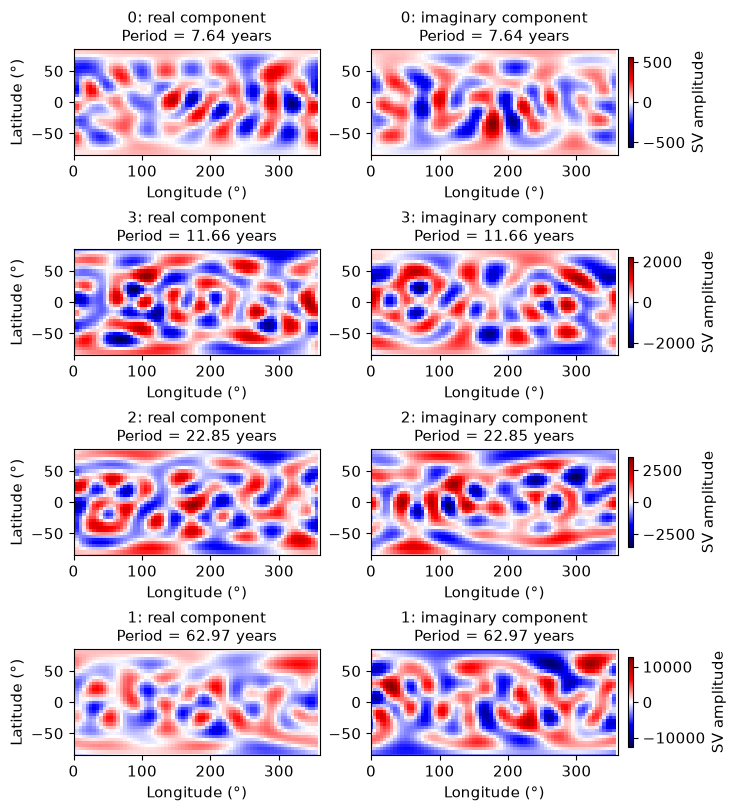

In [139]:
Plot_Mode_Phasors(recovered_suite)

In [40]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from pathlib import Path


def Plot_Mode_Suite_Video_Mollweide(
    mode_suite,
    times_used_relative,
    output_path,
    mode_keys=None,
    state_shape=state_shape,
    longitude=longitude,
    latitude=latitude,
    design_matrix=A_15_r,
    nmax=None,
    fps=5,
    dpi=150,
    figure_width=10,
    cmap="seismic",
    scale="per_mode",
    show_colorbars=False,
    sort_by_period=True,
    font_size=11,
):
    """
    Create one video showing the real reconstructed field for several modes,
    with one Mollweide subplot per row.

    Each row shows:
        x(t) = Re[ phasor * exp(eigenvalue * t) ]

    Compatible with dictionaries containing either:
        - 'gnm_phasor' and 'true_eigenvalue'
        - 'phasor' and 'eigenvalue'

    Period may be stored as:
        - 'true_period'
        - 'period'
    """

    times = np.asarray(times_used_relative, dtype=float).ravel()
    if times.size == 0:
        raise ValueError("times_used_relative is empty.")

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    expected_grid_size = int(np.prod(state_shape))

    # ------------------------------------------------------------------
    # Helper functions
    # ------------------------------------------------------------------

    def infer_nmax_from_gauss(gauss_phasor):
        n_coefficients = np.asarray(gauss_phasor).size
        inferred_nmax = int(np.sqrt(n_coefficients + 1) - 1)
        expected_coefficients = inferred_nmax * (inferred_nmax + 2)

        if expected_coefficients != n_coefficients:
            raise ValueError(
                f"Cannot infer nmax from {n_coefficients} coefficients."
            )

        return inferred_nmax

    def get_eigenvalue(mode_info):
        if "true_eigenvalue" in mode_info:
            return complex(mode_info["true_eigenvalue"])
        if "eigenvalue" in mode_info:
            return complex(mode_info["eigenvalue"])

        raise KeyError(
            "Mode entry must contain 'true_eigenvalue' or 'eigenvalue'."
        )

    def get_period(mode_info, eigenvalue):
        if "true_period" in mode_info:
            return float(mode_info["true_period"])
        if "period" in mode_info:
            return float(mode_info["period"])

        if np.isclose(eigenvalue.imag, 0.0):
            return np.inf

        return 2.0 * np.pi / np.abs(eigenvalue.imag)

    def get_grid_phasor(mode_info):
        if "gnm_phasor" in mode_info:
            gauss_phasor = np.asarray(
                mode_info["gnm_phasor"],
                dtype=complex,
            ).ravel()

            available_nmax = infer_nmax_from_gauss(gauss_phasor)

            if nmax is None:
                nmax_used = available_nmax
            else:
                nmax_used = min(int(nmax), available_nmax)

            gauss_phasor = Truncate_Gauss_Coeffs(
                gauss_phasor,
                tmax=nmax_used,
            )

            A_used = Truncate_Gauss_Coeffs(
                design_matrix,
                tmax=nmax_used,
            )

            grid_phasor = A_used @ gauss_phasor

        elif "phasor" in mode_info:
            grid_phasor = np.asarray(
                mode_info["phasor"],
                dtype=complex,
            ).ravel()

        else:
            raise KeyError(
                "Mode entry must contain either 'gnm_phasor' or 'phasor'."
            )

        if grid_phasor.size != expected_grid_size:
            raise ValueError(
                f"Mode phasor has length {grid_phasor.size}, "
                f"but expected {expected_grid_size}."
            )

        return grid_phasor

    # ------------------------------------------------------------------
    # Select valid modes
    # ------------------------------------------------------------------

    ignored_keys = {"match_count", "convergence_count"}

    valid_mode_keys = [
        key
        for key, value in mode_suite.items()
        if (
            key not in ignored_keys
            and isinstance(value, dict)
            and ("phasor" in value or "gnm_phasor" in value)
        )
    ]

    if mode_keys is None:
        mode_keys = valid_mode_keys
    else:
        mode_keys = list(mode_keys)

    if len(mode_keys) == 0:
        raise ValueError("No valid modes were found.")

    # ------------------------------------------------------------------
    # Prepare longitude ordering for Mollweide
    # ------------------------------------------------------------------

    # Convert 0..360 to -180..180 and sort for proper Mollweide display
    lon_wrapped_deg = ((np.asarray(longitude) + 180) % 360) - 180
    lon_sort_idx = np.argsort(lon_wrapped_deg)
    lon_plot_deg = lon_wrapped_deg[lon_sort_idx]
    lat_plot_deg = np.asarray(latitude)

    lon_plot_rad = np.deg2rad(lon_plot_deg)
    lat_plot_rad = np.deg2rad(lat_plot_deg)

    lon2d, lat2d = np.meshgrid(lon_plot_rad, lat_plot_rad)

    # ------------------------------------------------------------------
    # Build mode cubes
    # ------------------------------------------------------------------

    mode_data = {}

    for mode_key in mode_keys:
        mode_info = mode_suite[mode_key]

        eigenvalue = get_eigenvalue(mode_info)
        period = get_period(mode_info, eigenvalue)
        phasor = get_grid_phasor(mode_info)

        physical_series = np.real(
            phasor[None, :] * np.exp(eigenvalue * times[:, None])
        )

        physical_cube = physical_series.reshape(
            len(times),
            *state_shape,
        )

        # reorder longitude dimension for Mollweide
        physical_cube = physical_cube[:, :, lon_sort_idx]

        mode_data[mode_key] = {
            "eigenvalue": eigenvalue,
            "period": period,
            "cube": physical_cube,
        }

    if sort_by_period:
        mode_keys = sorted(
            mode_keys,
            key=lambda k: mode_data[k]["period"]
        )

    # ------------------------------------------------------------------
    # Colour scales
    # ------------------------------------------------------------------

    if scale == "per_mode":
        colour_limits = {
            key: np.nanmax(np.abs(mode_data[key]["cube"]))
            for key in mode_keys
        }
    elif scale == "global":
        global_limit = np.nanmax([
            np.nanmax(np.abs(mode_data[key]["cube"]))
            for key in mode_keys
        ])
        colour_limits = {key: global_limit for key in mode_keys}
    else:
        raise ValueError("scale must be 'per_mode' or 'global'.")

    for key in mode_keys:
        if not np.isfinite(colour_limits[key]) or colour_limits[key] == 0:
            colour_limits[key] = 1.0

    # ------------------------------------------------------------------
    # Figure
    # ------------------------------------------------------------------

    n_modes = len(mode_keys)
    fig_height = 3.2 * n_modes

    fig = plt.figure(figsize=(figure_width, fig_height))

    axes = []
    meshes = []

    for i, mode_key in enumerate(mode_keys):
        ax = fig.add_subplot(
            n_modes,
            1,
            i + 1,
            projection="mollweide",
        )
        axes.append(ax)

        cube = mode_data[mode_key]["cube"]
        period = mode_data[mode_key]["period"]
        sigma = mode_data[mode_key]["eigenvalue"].real
        clim = colour_limits[mode_key]

        mesh = ax.pcolormesh(
            lon2d,
            lat2d,
            cube[0],
            shading="auto",
            cmap=cmap,
            vmin=-clim,
            vmax=clim,
        )
        meshes.append(mesh)

        if np.isfinite(period):
            period_text = f"{period:.2f} yr"
        else:
            period_text = "static"

        ax.set_title(
            f"{mode_key}   |   Period = {period_text}   |   σ = {sigma:.3f} yr$^{{-1}}$",
            fontsize=font_size,
            pad=12,
        )

        ax.grid(True, alpha=0.4)

        if show_colorbars:
            cbar = fig.colorbar(
                mesh,
                ax=ax,
                orientation="horizontal",
                pad=0.08,
                fraction=0.05,
            )
            cbar.ax.tick_params(labelsize=font_size - 1)

    time_text = fig.suptitle(
        f"t = {times[0]:.2f} years",
        fontsize=font_size + 1,
        y=0.995,
    )

    fig.subplots_adjust(
        left=0.05,
        right=0.95,
        top=0.97,
        bottom=0.03,
        hspace=0.30,
    )

    # ------------------------------------------------------------------
    # Animation
    # ------------------------------------------------------------------

    def update(frame):
        for mode_key, mesh in zip(mode_keys, meshes):
            data = mode_data[mode_key]["cube"][frame]
            mesh.set_array(data.ravel())

        time_text.set_text(f"t = {times[frame]:.2f} years")
        return meshes + [time_text]

    animation = FuncAnimation(
        fig,
        update,
        frames=len(times),
        interval=1000 / fps,
        blit=False,
    )

    writer = FFMpegWriter(fps=fps)
    animation.save(output_path, writer=writer, dpi=dpi)

    plt.close(fig)

    print(f"Saved video to: {output_path}")

    return output_path

In [41]:
Plot_Mode_Suite_Video_Mollweide(
    mode_suite=recovered_suite,
    times_used_relative=times_used_relative,
    output_path=FIG_DIR / "control_modes_mollweide.mp4",
    mode_keys=recovered_suite.keys(),
    fps=5,
    figure_width=10,
    scale="per_mode",
    show_colorbars=False,
)

Saved video to: /home/elliott/projects/msc_thesis_project/figures/control_modes_mollweide.mp4


PosixPath('/home/elliott/projects/msc_thesis_project/figures/control_modes_mollweide.mp4')